# 📊 TelecomX Parte 2- Predicción de Fuga de Clientes (Churn)
## Machine Learning y Modelado Predictivo

---

**Proyecto:** Sistema de Predicción de Cancelación de Clientes  
**Analista:** Daniela Puebla  
**Rol:** Analista Junior de Machine Learning  
**Fecha:** Marzo 2026

---

### 🎯 Contexto del Proyecto

**TelecomX LATAM** enfrenta una creciente pérdida de clientes que impacta directamente su rentabilidad. La dirección ha solicitado un sistema de inteligencia predictiva capaz de **anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios**.

En la **Parte 1** de este proyecto, realizamos una exhaustiva exploración, limpieza y transformación de los datos desde la API original (formato JSON) hasta un dataset estructurado y listo para Machine Learning.

En esta **Parte 2**, desarrollamos el pipeline completo de modelado predictivo siguiendo las mejores prácticas de la industria.

---

### 🧠 Objetivos de Esta Etapa

1. ✅ **Preparar los datos** para modelado (codificación, normalización)
2. ✅ **Analizar correlaciones** y seleccionar las variables más relevantes
3. ✅ **Entrenar múltiples modelos** de clasificación (Random Forest, XGBoost, Regresión Logística)
4. ✅ **Evaluar el rendimiento** con métricas robustas (Accuracy, Precision, Recall, F1, ROC-AUC)
5. ✅ **Interpretar resultados** usando SHAP y feature importance
6. ✅ **Generar conclusiones estratégicas** para la toma de decisiones de negocio

---

### 🧰 Tecnologías y Librerías

- **Preprocesamiento:** Pandas, NumPy, Scikit-learn
- **Visualización:** Matplotlib, Seaborn, Plotly
- **Modelado:** Random Forest, XGBoost, Logistic Regression
- **Interpretabilidad:** SHAP (SHapley Additive exPlanations)
- **Evaluación:** Scikit-learn Metrics, Confusion Matrix, ROC-AUC

---

### 🔄 Pipeline de Machine Learning

Este proyecto sigue un flujo estructurado de trabajo que transforma datos en decisiones estratégicas:

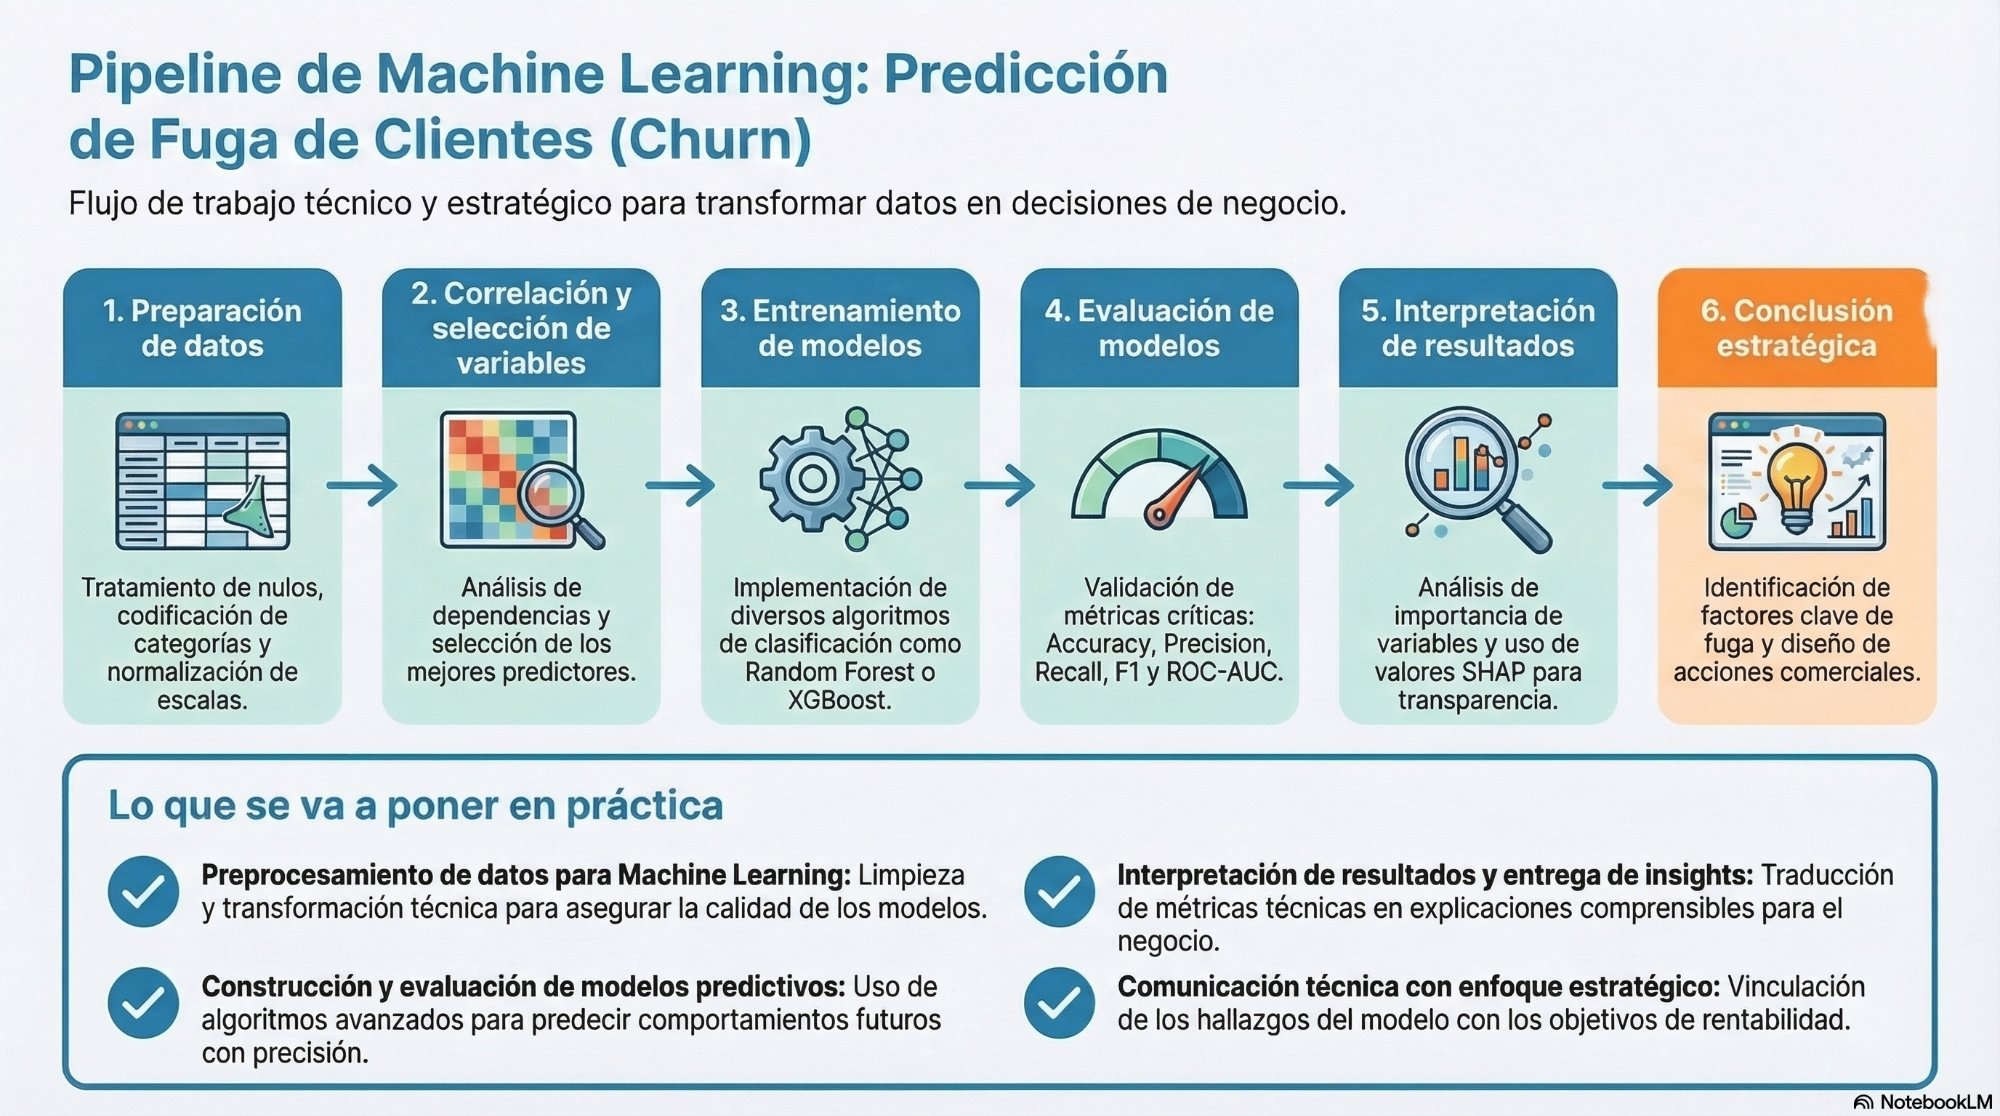

---

**Descripción del Pipeline:**

1. **📊 Preparación de datos:** Tratamiento de nulos, codificación categórica, normalización de escalas
2. **🔍 Correlación y selección:** Análisis de dependencias y selección de los mejores predictores
3. **⚙️ Entrenamiento:** Implementación de algoritmos como Random Forest, XGBoost y Regresión Logística
4. **📈 Evaluación:** Validación con métricas críticas (Accuracy, Precision, Recall, F1, ROC-AUC)
5. **🔬 Interpretación:** Análisis de importancia de variables y SHAP values para transparencia
6. **💡 Conclusión estratégica:** Identificación de factores clave y diseño de acciones comerciales

---

## 📦 1. Configuración del Entorno

### 1.1 Importación de Librerías Necesarias

Comenzamos importando todas las herramientas que utilizaremos en este análisis:

In [1]:
# ============================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Modelos de Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Interpretabilidad
import shap

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Carga del Dataset Limpio

Cargamos el dataset `telecomx_limpio.csv` que fue preprocesado en la **Parte 1** del proyecto.

**Recordatorio de la Parte 1:**
- ✅ Datos extraídos desde API (formato JSON)
- ✅ Limpieza de valores nulos y duplicados
- ✅ Transformación de tipos de datos
- ✅ Creación de variables derivadas
- ✅ Análisis exploratorio inicial

In [2]:
# Carga del dataset limpio
df = pd.read_csv('/content/telecomx_limpio.csv')

# Vista general del dataset
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("="*50)
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*50)

# Primeras filas
df.head()

📊 INFORMACIÓN GENERAL DEL DATASET
Dimensiones: 7,267 filas x 23 columnas

Memoria utilizada: 7.07 MB



,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Tipo_Internet,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binaria
0,0002-ORFBO,No,Femenino,0,Sí,Sí,9,Sí,No,DSL,No,Sí,No,Sí,Sí,No,One year,Sí,Mailed check,65.6,593.30,2.19,0.0
1,0003-MKNFE,No,Masculino,0,No,No,9,Sí,Sí,DSL,No,No,No,No,No,Sí,Month-to-month,No,Mailed check,59.9,542.40,2.00,0.0
2,0004-TLHLJ,Sí,Masculino,0,No,No,4,Sí,No,Fiber optic,No,No,Sí,No,No,No,Month-to-month,Sí,Electronic check,73.9,280.85,2.46,1.0
3,0011-IGKFF,Sí,Masculino,1,Sí,No,13,Sí,No,Fiber optic,No,Sí,Sí,No,Sí,Sí,Month-to-month,Sí,Electronic check,98.0,1237.85,3.27,1.0
4,0013-EXCHZ,Sí,Femenino,1,Sí,No,3,Sí,No,Fiber optic,No,No,No,Sí,Sí,No,Month-to-month,Sí,Mailed check,83.9,267.40,2.80,1.0


In [3]:
# Información detallada del dataset
print("📋 ESTRUCTURA DE DATOS")
print("="*50)
df.info()

print("\n📊 ESTADÍSTICAS DESCRIPTIVAS")
print("="*50)
df.describe()

📋 ESTRUCTURA DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Evasion                 7043 non-null   object 
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Tiene_Pareja            7267 non-null   object 
 5   Tiene_Dependientes      7267 non-null   object 
 6   Meses_Contrato          7267 non-null   int64  
 7   Servicio_Telefono       7267 non-null   object 
 8   Multiples_Lineas        7267 non-null   object 
 9   Tipo_Internet           7267 non-null   object 
 10  Seguridad_Online        5686 non-null   object 
 11  Backup_Online           5686 non-null   object 
 12  Proteccion_Dispositivo  5686 non-null   object 
 13  Soporte_Tecnico         5686 non-null   object 
 14  Streaming_TV      

,Adulto_Mayor,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binaria
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7043.000000
mean,0.162653,32.346498,64.720098,2277.182035,2.157292,0.265370
std,0.369074,24.571773,30.129572,2268.648587,1.004407,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.610000,0.000000
25%,0.000000,9.000000,35.425000,396.200000,1.180000,0.000000
50%,0.000000,29.000000,70.300000,1389.200000,2.340000,0.000000
75%,0.000000,55.000000,89.875000,3778.525000,2.995000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.960000,1.000000


In [8]:
df.columns

Index(['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefono',
       'Multiples_Lineas', 'Tipo_Internet', 'Seguridad_Online',
       'Backup_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato',
       'Factura_Digital', 'Metodo_Pago', 'Cargos_Mensuales', 'Cargos_Totales',
       'Cuentas_Diarias', 'Evasion_Binaria'],
      dtype='object')

---

## 📊 2. Análisis de la Variable Objetivo  "Churn (Evasión en español)

### 2.1 Distribución de Churn

Antes de comenzar con el modelado, es fundamental entender la distribución de nuestra variable objetivo.
Esto nos permitirá:
- Identificar si existe **desbalance de clases**
- Definir la **métrica de evaluación** más apropiada
- Determinar si necesitamos técnicas de **balanceo** (SMOTE, undersampling, etc.)

In [9]:
# Análisis de la variable objetivo
print("🎯 ANÁLISIS DE CHURN ")
print("\n📌la columna Churn fue Renombrada al Español como 'Evasion_Binaria'. \n el cambio viene desde notebook anteior ")
print("\n📊 Distribución de la variable objetivo 'Evasion_Binaria':")
print("="*60)

churn_counts = df['Evasion_Binaria'].value_counts()
churn_pct = df['Evasion_Binaria'].value_counts(normalize=True) * 100

print("\n📊 Distribución Absoluta:")
print(churn_counts)

print("\n📈 Distribución Porcentual:")
for clase, pct in churn_pct.items():
    print(f"  {clase}: {pct:.2f}%")

# Calcular ratio de desbalance
ratio = churn_counts.max() / churn_counts.min()
print(f"\n⚖️ Ratio de desbalance: {ratio:.2f}:1")

if ratio > 3:
    print("\n⚠️ ALERTA: Dataset desbalanceado detectado")
    print("   Recomendación: Considerar técnicas de balanceo o ajustar métricas")
else:
    print("\n✅ Dataset relativamente balanceado")

🎯 ANÁLISIS DE CHURN 

📌la columna Churn fue Renombrada al Español como 'Evasion_Binaria'. 
 el cambio viene desde notebook anteior 

📊 Distribución de la variable objetivo 'Evasion_Binaria':

📊 Distribución Absoluta:
Evasion_Binaria
0.0    5174
1.0    1869
Name: count, dtype: int64

📈 Distribución Porcentual:
  0.0: 73.46%
  1.0: 26.54%

⚖️ Ratio de desbalance: 2.77:1

✅ Dataset relativamente balanceado


In [30]:
# VERIFICACIÓN
print("🔍 VERIFICACIÓN DE CORRECCIONES:")
print("="*50)

# 1. Verificar que Evasion_Binaria existe
assert 'Evasion_Binaria' in df_cleaned.columns, "❌ Falta Evasion_Binaria"
print("✅ Evasion_Binaria existe")

# 2. Verificar valores
assert set(df_cleaned['Evasion_Binaria'].unique()) == {0.0, 1.0}, "❌ Valores incorrectos"
print("✅ Evasion_Binaria tiene valores 0 y 1")

# 3. Verificar X no tiene columnas excluidas
assert 'ID_Cliente' not in X.columns, "❌ ID_Cliente no debería estar en X"
assert 'Evasion' not in X.columns, "❌ Evasion no debería estar en X"
assert 'Evasion_Binaria' not in X.columns, "❌ Evasion_Binaria no debería estar en X"
print("✅ X no contiene columnas excluidas")

# 4. Verificar dimensiones
assert X.shape[0] == y.shape[0], "❌ X e y tienen diferente número de filas"
print(f"✅ Dimensiones correctas: X={X.shape}, y={y.shape}")

print("\n🎉 ¡TODAS LAS VERIFICACIONES PASARON!")

🔍 VERIFICACIÓN DE CORRECCIONES:
✅ Evasion_Binaria existe
✅ Evasion_Binaria tiene valores 0 y 1
✅ X no contiene columnas excluidas
✅ Dimensiones correctas: X=(7043, 25), y=(7043,)

🎉 ¡TODAS LAS VERIFICACIONES PASARON!


In [ ]:
# Visualización de la distribución de Churn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
churn_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Distribución de Churn (Absoluta)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Evasion_Binaria', fontsize=12)
ax1.set_ylabel('Cantidad de Clientes', fontsize=12)
ax1.set_xticklabels(['No Churn', 'Evasion_Binaria'], rotation=0)

# Agregar valores sobre las barras
for i, v in enumerate(churn_counts):
    ax1.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de pastel
colors = ['#2ecc71', '#e74c3c']
ax2.pie(churn_counts, labels=['No Churn', 'Evasion_Binaria'], autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Distribución de Churn (Porcentual)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Esta distribución influirá en la selección de métricas de evaluación")

---

## 🛠️ 3. Preparación de Datos para Machine Learning

### 3.1 Identificación de Tipos de Variables

Para aplicar las transformaciones correctas, primero identificamos los tipos de variables en nuestro dataset:

In [ ]:
# Identificar tipos de variables
print("🔍 IDENTIFICACIÓN DE TIPOS DE VARIABLES")
print("="*60)

# Separar por tipo de dato
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Remover la variable objetivo de las listas
if 'Evasion_Binaria' in numericas:
    numericas.remove('Evasion_Binaria')
if 'Evasion_Binaria' in categoricas:
    categoricas.remove('Evasion_Binaria')

print(f"\n📊 Variables Numéricas ({len(numericas)}):")
for var in numericas:
    print(f"  • {var}")

print(f"\n🏷️ Variables Categóricas ({len(categoricas)}):")
for var in categoricas:
    unique_count = df[var].nunique()
    print(f"  • {var} ({unique_count} categorías)")

print(f"\n🎯 Variable Objetivo: Churn")

### 3.2 Tratamiento de Valores Nulos

Verificamos la presencia de valores nulos antes de proceder con el modelado:

In [ ]:
# Verificar valores nulos
print("🔎 VERIFICACIÓN DE VALORES NULOS")
print("="*60)

nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100

# Crear dataframe de nulos
nulos_df = pd.DataFrame({
    'Variable': nulos.index,
    'Nulos': nulos.values,
    'Porcentaje': nulos_pct.values
})

# Filtrar solo las que tienen nulos
nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(nulos_df) > 0:
    print("\n⚠️ Variables con valores nulos:")
    print(nulos_df.to_string(index=False))
    print("\n💡 Se requiere imputación o eliminación de estas variables")
else:
    print("\n✅ No se encontraron valores nulos en el dataset")
    print("   El dataset está listo para codificación y normalización")

### 3.3 Codificación de Variables Categóricas

Los algoritmos de Machine Learning requieren datos numéricos. Aplicamos diferentes técnicas de codificación:

- **Label Encoding:** Para variables binarias (ej: Yes/No, Male/Female)
- **One-Hot Encoding:** Para variables con múltiples categorías sin orden

**Importante:** Codificamos la variable objetivo (Churn) usando Label Encoding.

In [ ]:
# Crear copia para no modificar el dataset original
df_encoded = df.copy()

print("🔄 CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)

# Codificar variable objetivo (Churn)
if df_encoded['Evasion_Binaria'].dtype == 'object':
    le_churn = LabelEncoder()
    df_encoded['Evasion_Binaria'] = le_churn.fit_transform(df_encoded['Evasion_Binaria'])
    print(f"\n🎯 Variable objetivo codificada:")
    print(f"   {dict(zip(le_churn.classes_, le_churn.transform(le_churn.classes_)))}")

# Identificar variables binarias (2 valores únicos)
variables_binarias = [col for col in categoricas if df[col].nunique() == 2]

# Label Encoding para variables binarias
if variables_binarias:
    print(f"\n📌 Label Encoding aplicado a {len(variables_binarias)} variables binarias:")
    for col in variables_binarias:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"   • {col}: {mapping}")

# One-Hot Encoding para variables con múltiples categorías
variables_multiclase = [col for col in categoricas if df[col].nunique() > 2]

if variables_multiclase:
    print(f"\n📌 One-Hot Encoding aplicado a {len(variables_multiclase)} variables:")
    df_encoded = pd.get_dummies(df_encoded, columns=variables_multiclase, drop_first=True)
    for col in variables_multiclase:
        nuevas_cols = [c for c in df_encoded.columns if c.startswith(col + '_')]
        print(f"   • {col} → {len(nuevas_cols)} nuevas columnas")

print(f"\n✅ Codificación completada")
print(f"   Dimensiones finales: {df_encoded.shape[0]:,} filas x {df_encoded.shape[1]} columnas")

### 3.4 Normalización de Variables Numéricas

La normalización es crucial para:
- **Mejorar la convergencia** de algoritmos como Regresión Logística
- **Equilibrar la importancia** de variables con diferentes escalas
- **Optimizar el rendimiento** de modelos basados en distancias

Utilizamos **StandardScaler** que transforma cada variable a:
- Media = 0
- Desviación estándar = 1

In [12]:
# Identificar tipos de variables (moved from a previous cell)
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Remove the target variable and ID from these lists for processing
if 'Evasion_Binaria' in numericas:
    numericas.remove('Evasion_Binaria')
if 'Evasion' in categoricas:
    categoricas.remove('Evasion')
if 'ID_Cliente' in categoricas:
    categoricas.remove('ID_Cliente')

# Create a copy for encoding (moved from a previous cell)
df_encoded = df.copy()

# Encode target variable (moved from a previous cell)
if df_encoded['Evasion_Binaria'].dtype == 'object':
    le_churn = LabelEncoder()
    df_encoded['Evasion_Binaria'] = le_churn.fit_transform(df_encoded['Evasion_Binaria'])

# Identify binary variables (2 unique values)
variables_binarias = [col for col in categoricas if df[col].nunique() == 2]

# Label Encoding for binary variables (moved from a previous cell)
if variables_binarias:
    for col in variables_binarias:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

# One-Hot Encoding for multi-class variables (moved from a previous cell)
variables_multiclase = [col for col in categoricas if df[col].nunique() > 2]
if variables_multiclase:
    df_encoded = pd.get_dummies(df_encoded, columns=variables_multiclase, drop_first=True)

# Handle nulls in 'Evasion_Binaria' after encoding (from previous fix attempt)
df_encoded_cleaned = df_encoded.dropna(subset=['Evasion_Binaria'])
df_cleaned = df.dropna(subset=['Evasion_Binaria'])

# Separar features y target
X = df_encoded_cleaned.drop(['ID_Cliente', 'Evasion', 'Evasion_Binaria'], axis=1)
y = df_cleaned['Evasion_Binaria']  # Usar df original, no df_encoded

print(f"✅ Shape X: {X.shape}")
print(f"✅ Shape y: {y.shape}")
print(f"✅ Distribución y: {y.value_counts().to_dict()}")

# Identificar columnas numéricas (excluyendo las codificadas como binarias)
columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔄 NORMALIZACIÓN DE VARIABLES NUMÉRICAS")
print("="*60)
print(f"\nVariables a normalizar: {len(columnas_numericas)}")

# Crear copia para normalización
X_normalized = X.copy()

if columnas_numericas:
    # Aplicar StandardScaler
    scaler = StandardScaler()
    X_normalized[columnas_numericas] = scaler.fit_transform(X[columnas_numericas])

    print("\n✅ Normalización aplicada con StandardScaler")
    print("\n📊 Ejemplo de transformación (primeras 3 variables):")

    for col in columnas_numericas[:3]:
        print(f"\n   {col}:")
        print(f"      Original  → Media: {X[col].mean():.2f}, Std: {X[col].std():.2f}")
        print(f"      Normaliz. → Media: {X_normalized[col].mean():.2f}, Std: {X_normalized[col].std():.2f}")
else:
    print("\n⚠️ No se encontraron variables numéricas para normalizar")

print(f"\n📏 Dimensiones finales de X: {X_normalized.shape}")
print(f"📊 Dimensión de y: {y.shape}")

✅ Shape X: (7043, 25)
✅ Shape y: (7043,)
✅ Distribución y: {0.0: 5174, 1.0: 1869}
🔄 NORMALIZACIÓN DE VARIABLES NUMÉRICAS

Variables a normalizar: 16

✅ Normalización aplicada con StandardScaler

📊 Ejemplo de transformación (primeras 3 variables):

   Genero:
      Original  → Media: 0.50, Std: 0.50
      Normaliz. → Media: -0.00, Std: 1.00

   Adulto_Mayor:
      Original  → Media: 0.16, Std: 0.37
      Normaliz. → Media: -0.00, Std: 1.00

   Tiene_Pareja:
      Original  → Media: 0.48, Std: 0.50
      Normaliz. → Media: 0.00, Std: 1.00

📏 Dimensiones finales de X: (7043, 25)
📊 Dimensión de y: (7043,)


---

## 🔍 4. Análisis de Correlación y Selección de Variables

### 4.1 Matriz de Correlación

El análisis de correlación nos permite:
1. **Identificar multicolinealidad** entre variables independientes
2. **Detectar las variables más relevantes** para predecir Churn
3. **Reducir la dimensionalidad** eliminando variables redundantes

**Interpretación:**
- Correlación > 0.7: Correlación fuerte positiva
- Correlación < -0.7: Correlación fuerte negativa
- Correlación cercana a 0: Sin relación lineal

In [13]:
# Crear dataset completo con target para análisis de correlación
df_correlation = X_normalized.copy()
df_correlation['Evasion_Binaria'] = y

# Calcular matriz de correlación
correlation_matrix = df_correlation.corr()

print("📊 ANÁLISIS DE CORRELACIÓN")
print("="*60)
print(f"\nDimensiones de la matriz: {correlation_matrix.shape}")

📊 ANÁLISIS DE CORRELACIÓN

Dimensiones de la matriz: (26, 26)


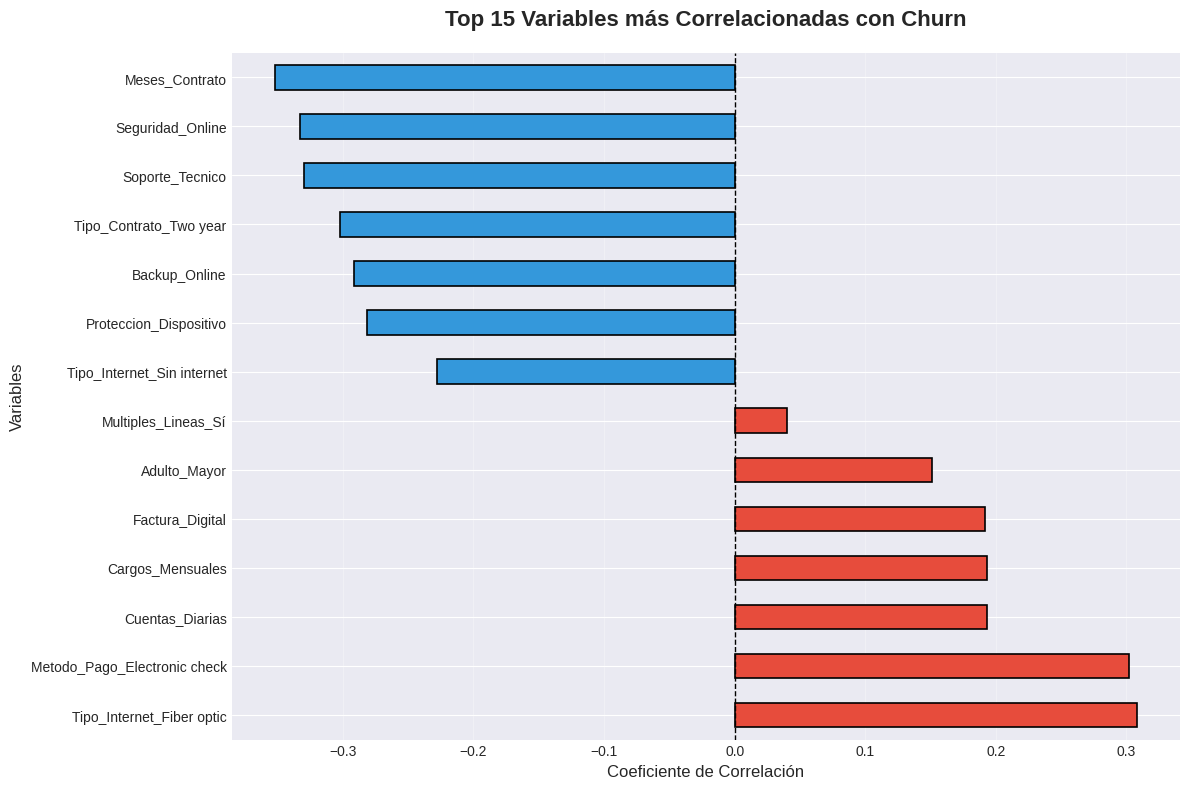


📈 Top 10 Correlaciones Positivas con Churn:
Tipo_Internet_Fiber optic                   0.308020
Metodo_Pago_Electronic check                0.301919
Cuentas_Diarias                             0.193412
Cargos_Mensuales                            0.193356
Factura_Digital                             0.191825
Adulto_Mayor                                0.150889
Multiples_Lineas_Sí                         0.040102
Servicio_Telefono                           0.011942
Genero                                     -0.008612
Multiples_Lineas_Sin servicio telefónico   -0.011942
Name: Evasion_Binaria, dtype: float64

📉 Top 10 Correlaciones Negativas con Churn:
Cargos_Totales               -0.198324
Streaming_TV                 -0.205742
Streaming_Peliculas          -0.207256
Tipo_Internet_Sin internet   -0.227890
Proteccion_Dispositivo       -0.281465
Backup_Online                -0.291449
Tipo_Contrato_Two year       -0.302253
Soporte_Tecnico              -0.329852
Seguridad_Online             -

In [14]:
# Visualización de la matriz de correlación (top variables)
# Seleccionar solo las correlaciones con Churn
churn_correlations = correlation_matrix['Evasion_Binaria'].sort_values(ascending=False)

# Excluir la correlación de Churn consigo mismo
churn_correlations = churn_correlations[churn_correlations.index != 'Evasion_Binaria']

# Top 15 variables más correlacionadas (positiva y negativamente)
top_n = 15
top_positive = churn_correlations.head(top_n//2)
top_negative = churn_correlations.tail(top_n//2)
top_correlations = pd.concat([top_positive, top_negative]).sort_values(ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_correlations.values]
top_correlations.plot(kind='barh', color=colors, edgecolor='black', linewidth=1.2)
plt.title('Top 15 Variables más Correlacionadas con Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coeficiente de Correlación', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📈 Top 10 Correlaciones Positivas con Churn:")
print(churn_correlations.head(10))

print("\n📉 Top 10 Correlaciones Negativas con Churn:")
print(churn_correlations.tail(10))

### 4.2 Detección de Multicolinealidad

La multicolinealidad ocurre cuando dos o más variables independientes están altamente correlacionadas entre sí.

**Problema:** Puede afectar la interpretabilidad del modelo y la estabilidad de los coeficientes.

**Criterio:** Identificamos pares de variables con correlación > 0.85

In [15]:
# Detectar multicolinealidad
print("🔍 DETECCIÓN DE MULTICOLINEALIDAD")
print("="*60)

# Matriz de correlación absoluta (sin la variable target)
corr_matrix_features = X_normalized.corr().abs()

# Obtener la matriz triangular superior
upper_triangle = corr_matrix_features.where(
    np.triu(np.ones(corr_matrix_features.shape), k=1).astype(bool)
)

# Encontrar pares con correlación > 0.85
high_corr_pairs = []
for column in upper_triangle.columns:
    high_corr = upper_triangle[column][upper_triangle[column] > 0.85]
    for index in high_corr.index:
        high_corr_pairs.append((column, index, high_corr[index]))

if high_corr_pairs:
    print(f"\n⚠️ Se encontraron {len(high_corr_pairs)} pares con alta correlación (>0.85):")
    print("\n   Variable 1              Variable 2              Correlación")
    print("   " + "="*65)
    for var1, var2, corr in high_corr_pairs[:10]:  # Mostrar solo top 10
        print(f"   {var1:23} {var2:23} {corr:.3f}")

    if len(high_corr_pairs) > 10:
        print(f"   ... y {len(high_corr_pairs) - 10} pares más")

    print("\n💡 Recomendación: Considerar eliminar una variable de cada par")
else:
    print("\n✅ No se detectó multicolinealidad significativa (>0.85)")
    print("   Las variables pueden utilizarse sin problemas en el modelo")

🔍 DETECCIÓN DE MULTICOLINEALIDAD

⚠️ Se encontraron 2 pares con alta correlación (>0.85):

   Variable 1              Variable 2              Correlación
   Cuentas_Diarias         Cargos_Mensuales        1.000
   Multiples_Lineas_Sin servicio telefónico Servicio_Telefono       1.000

💡 Recomendación: Considerar eliminar una variable de cada par


### 4.3 División de Datos: Train y Test

Dividimos el dataset en conjuntos de entrenamiento y prueba:

- **Train (80%):** Para entrenar los modelos
- **Test (20%):** Para evaluar el rendimiento en datos no vistos

**Importante:** Utilizamos `stratify=y` para mantener la misma proporción de Churn en ambos conjuntos.

In [16]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✂️ DIVISIÓN DE DATOS")
print("="*60)
print(f"\n📊 Conjunto de Entrenamiento (Train):")
print(f"   • X_train: {X_train.shape[0]:,} filas x {X_train.shape[1]} columnas")
print(f"   • y_train: {y_train.shape[0]:,} etiquetas")
print(f"   • Distribución Churn: {y_train.value_counts().to_dict()}")

print(f"\n📊 Conjunto de Prueba (Test):")
print(f"   • X_test: {X_test.shape[0]:,} filas x {X_test.shape[1]} columnas")
print(f"   • y_test: {y_test.shape[0]:,} etiquetas")
print(f"   • Distribución Churn: {y_test.value_counts().to_dict()}")

print(f"\n✅ Datos listos para entrenamiento")

✂️ DIVISIÓN DE DATOS

📊 Conjunto de Entrenamiento (Train):
   • X_train: 5,634 filas x 25 columnas
   • y_train: 5,634 etiquetas
   • Distribución Churn: {0.0: 4139, 1.0: 1495}

📊 Conjunto de Prueba (Test):
   • X_test: 1,409 filas x 25 columnas
   • y_test: 1,409 etiquetas
   • Distribución Churn: {0.0: 1035, 1.0: 374}

✅ Datos listos para entrenamiento


---

## ⚙️ 5. Entrenamiento de Modelos de Clasificación

### 5.1 Selección de Algoritmos

Entrenaremos **tres modelos** diferentes para comparar su rendimiento:

1. **📊 Regresión Logística**
   - Modelo lineal, interpretable
   - Ideal como baseline
   - Rápido de entrenar

2. **🌳 Random Forest**
   - Conjunto de árboles de decisión
   - Captura relaciones no lineales
   - Robusto contra overfitting

3. **🚀 XGBoost**
   - Gradient Boosting optimizado
   - Alto rendimiento en competiciones
   - Excelente con datos desbalanceados

---

### 5.2 Modelo 1: Regresión Logística

In [17]:
# Entrenamiento de Regresión Logística
print("📊 ENTRENANDO REGRESIÓN LOGÍSTICA")
print("="*60)

# Crear y entrenar el modelo
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Métricas
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print("\n✅ Modelo entrenado exitosamente")
print("\n📈 MÉTRICAS DE EVALUACIÓN:")
print(f"   • Accuracy:  {lr_accuracy:.4f}")
print(f"   • Precision: {lr_precision:.4f}")
print(f"   • Recall:    {lr_recall:.4f}")
print(f"   • F1-Score:  {lr_f1:.4f}")
print(f"   • ROC-AUC:   {lr_roc_auc:.4f}")

📊 ENTRENANDO REGRESIÓN LOGÍSTICA

✅ Modelo entrenado exitosamente

📈 MÉTRICAS DE EVALUACIÓN:
   • Accuracy:  0.7935
   • Precision: 0.6352
   • Recall:    0.5214
   • F1-Score:  0.5727
   • ROC-AUC:   0.8431


### 5.3 Modelo 2: Random Forest

In [18]:
# Entrenamiento de Random Forest
print("🌳 ENTRENANDO RANDOM FOREST")
print("="*60)

# Crear y entrenar el modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=10
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("\n✅ Modelo entrenado exitosamente")
print("\n📈 MÉTRICAS DE EVALUACIÓN:")
print(f"   • Accuracy:  {rf_accuracy:.4f}")
print(f"   • Precision: {rf_precision:.4f}")
print(f"   • Recall:    {rf_recall:.4f}")
print(f"   • F1-Score:  {rf_f1:.4f}")
print(f"   • ROC-AUC:   {rf_roc_auc:.4f}")

🌳 ENTRENANDO RANDOM FOREST

✅ Modelo entrenado exitosamente

📈 MÉTRICAS DE EVALUACIÓN:
   • Accuracy:  0.7921
   • Precision: 0.6431
   • Recall:    0.4866
   • F1-Score:  0.5540
   • ROC-AUC:   0.8399


### 5.4 Modelo 3: XGBoost

In [19]:
# Entrenamiento de XGBoost
print("🚀 ENTRENANDO XGBOOST")
print("="*60)

# Crear y entrenar el modelo
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Métricas
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n✅ Modelo entrenado exitosamente")
print("\n📈 MÉTRICAS DE EVALUACIÓN:")
print(f"   • Accuracy:  {xgb_accuracy:.4f}")
print(f"   • Precision: {xgb_precision:.4f}")
print(f"   • Recall:    {xgb_recall:.4f}")
print(f"   • F1-Score:  {xgb_f1:.4f}")
print(f"   • ROC-AUC:   {xgb_roc_auc:.4f}")

🚀 ENTRENANDO XGBOOST

✅ Modelo entrenado exitosamente

📈 MÉTRICAS DE EVALUACIÓN:
   • Accuracy:  0.7842
   • Precision: 0.6182
   • Recall:    0.4893
   • F1-Score:  0.5463
   • ROC-AUC:   0.8395


---

## 📈 6. Evaluación y Comparación de Modelos

### 6.1 Tabla Comparativa de Métricas

**Interpretación de Métricas:**

- **Accuracy:** % de predicciones correctas (puede engañar con datos desbalanceados)
- **Precision:** De los que predijimos como Churn, ¿cuántos realmente lo son?
- **Recall:** De todos los que hicieron Churn, ¿cuántos detectamos?
- **F1-Score:** Balance armónico entre Precision y Recall
- **ROC-AUC:** Capacidad del modelo para discriminar entre clases

In [20]:
# Crear tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy],
    'Precision': [lr_precision, rf_precision, xgb_precision],
    'Recall': [lr_recall, rf_recall, xgb_recall],
    'F1-Score': [lr_f1, rf_f1, xgb_f1],
    'ROC-AUC': [lr_roc_auc, rf_roc_auc, xgb_roc_auc]
})

print("📊 COMPARACIÓN DE MODELOS")
print("="*80)
print(resultados.to_string(index=False))

# Identificar mejor modelo por métrica
print("\n🏆 MEJORES MODELOS POR MÉTRICA:")
print("="*80)
for metrica in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    mejor_idx = resultados[metrica].idxmax()
    mejor_modelo = resultados.loc[mejor_idx, 'Modelo']
    mejor_valor = resultados.loc[mejor_idx, metrica]
    print(f"   • {metrica:12}: {mejor_modelo:20} ({mejor_valor:.4f})")

📊 COMPARACIÓN DE MODELOS
             Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Regresión Logística  0.793471   0.635179 0.521390  0.572687 0.843113
      Random Forest  0.792051   0.643110 0.486631  0.554033 0.839904
            XGBoost  0.784244   0.618243 0.489305  0.546269 0.839515

🏆 MEJORES MODELOS POR MÉTRICA:
   • Accuracy    : Regresión Logística  (0.7935)
   • Precision   : Random Forest        (0.6431)
   • Recall      : Regresión Logística  (0.5214)
   • F1-Score    : Regresión Logística  (0.5727)
   • ROC-AUC     : Regresión Logística  (0.8431)


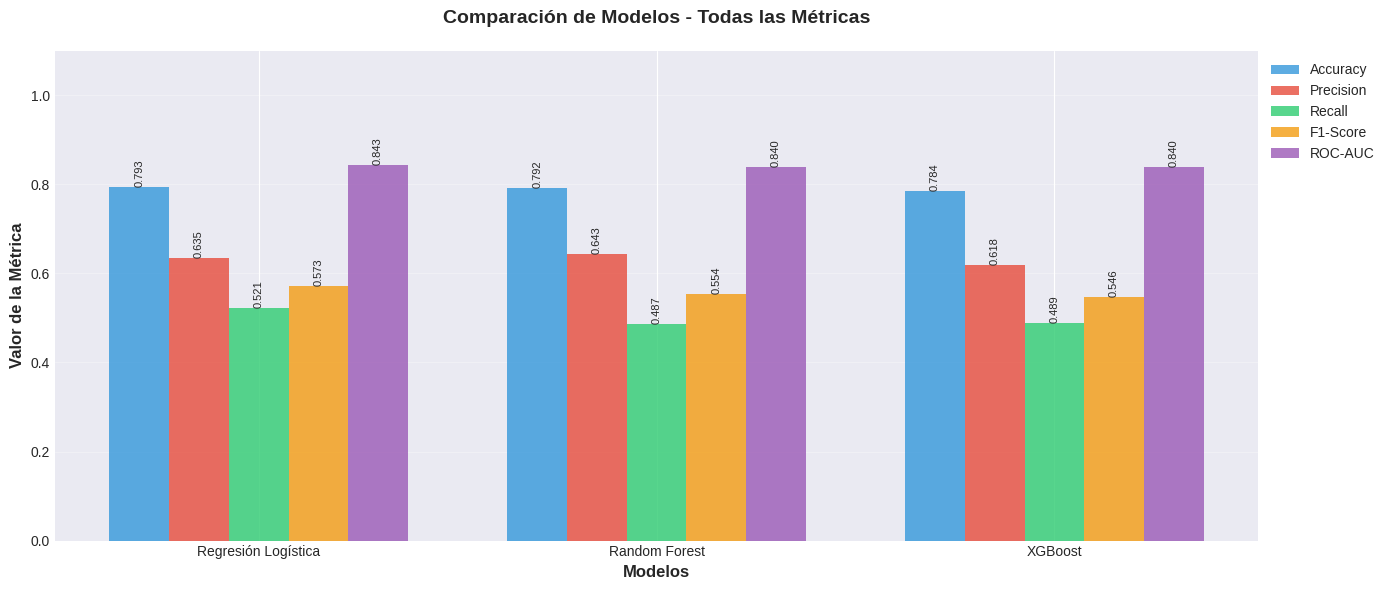

In [21]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(resultados))
width = 0.15

# Crear barras para cada métrica
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metrica, color) in enumerate(zip(metricas, colors)):
    offset = width * (i - 2)
    bars = ax.bar(x + offset, resultados[metrica], width, label=metrica, color=color, alpha=0.8)

    # Agregar valores sobre las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor de la Métrica', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Modelos - Todas las Métricas', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(resultados['Modelo'])
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

### 6.2 Matrices de Confusión

La matriz de confusión nos muestra:
- **Verdaderos Positivos (TP):** Predijimos Churn y era correcto
- **Verdaderos Negativos (TN):** Predijimos No Churn y era correcto
- **Falsos Positivos (FP):** Predijimos Churn pero estaba equivocado (Error Tipo I)
- **Falsos Negativos (FN):** Predijimos No Churn pero estaba equivocado (Error Tipo II)

**Para el negocio:**
- **FN es más costoso:** Perder un cliente que podíamos retener
- **FP tiene costo:** Invertir en retención de clientes que no se irían

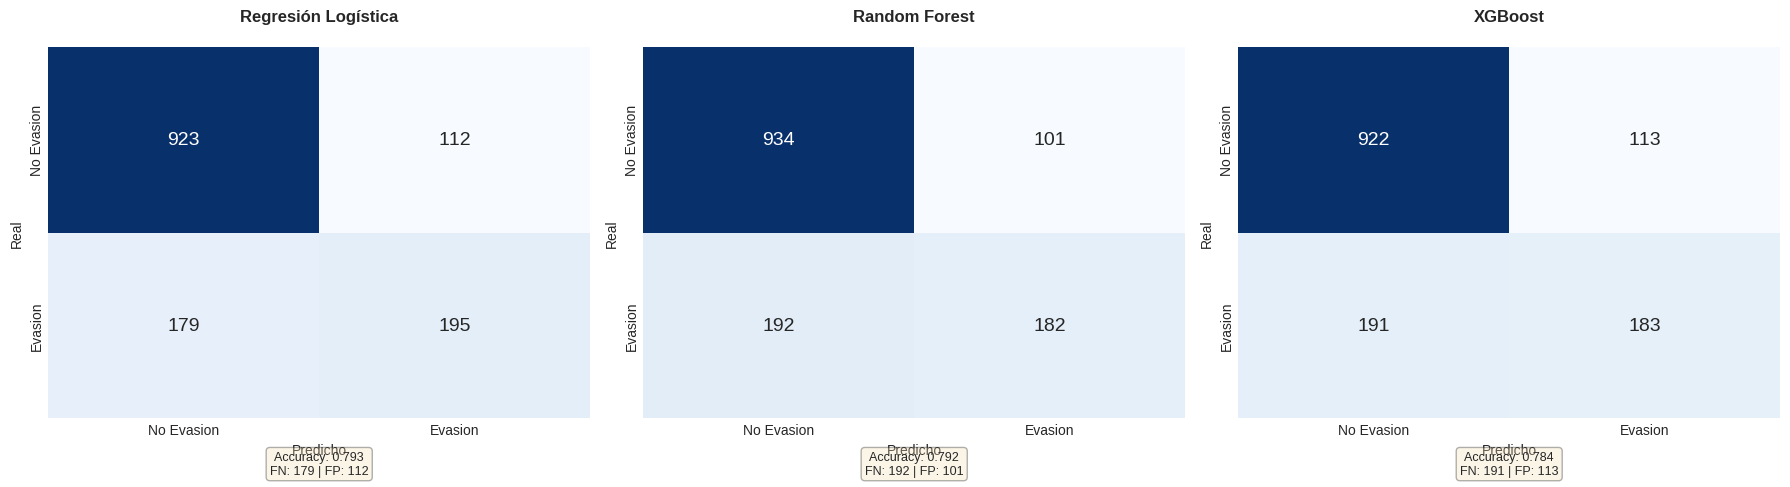


💡 Análisis de Costos de Negocio:
   • Falsos Negativos (FN): Clientes que se van pero no detectamos
   • Falsos Positivos (FP): Clientes que retenemos innecesariamente

   ⚖️ El modelo ideal minimiza FN para reducir pérdida de clientes


In [28]:
# Matrices de confusión para los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_pred = [
    ('Regresión Logística', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for idx, (nombre, y_pred) in enumerate(modelos_pred):
    cm = confusion_matrix(y_test, y_pred)

    # Visualización
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Evasion', 'Evasion'],
                yticklabels=['No Evasion', 'Evasion'],
                ax=axes[idx], cbar=False, annot_kws={'size': 14})

    axes[idx].set_title(f'{nombre}\n', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Real', fontsize=10)
    axes[idx].set_xlabel('Predicho', fontsize=10)

    # Agregar estadísticas
    tn, fp, fn, tp = cm.ravel()
    total_correct = tn + tp
    total = cm.sum()
    acc = total_correct / total

    stats_text = f'Accuracy: {acc:.3f}\nFN: {fn} | FP: {fp}'
    axes[idx].text(0.5, -0.15, stats_text,
                   ha='center', transform=axes[idx].transAxes,
                   fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n💡 Análisis de Costos de Negocio:")
print("   • Falsos Negativos (FN): Clientes que se van pero no detectamos")
print("   • Falsos Positivos (FP): Clientes que retenemos innecesariamente")
print("\n   ⚖️ El modelo ideal minimiza FN para reducir pérdida de clientes")

### 6.3 Curvas ROC (Receiver Operating Characteristic)

La curva ROC visualiza el trade-off entre:
- **Tasa de Verdaderos Positivos (TPR):** Sensibilidad / Recall
- **Tasa de Falsos Positivos (FPR):** 1 - Especificidad

**ROC-AUC (Area Under Curve):**
- 1.0 = Clasificador perfecto
- 0.5 = Clasificador aleatorio
- < 0.5 = Peor que aleatorio

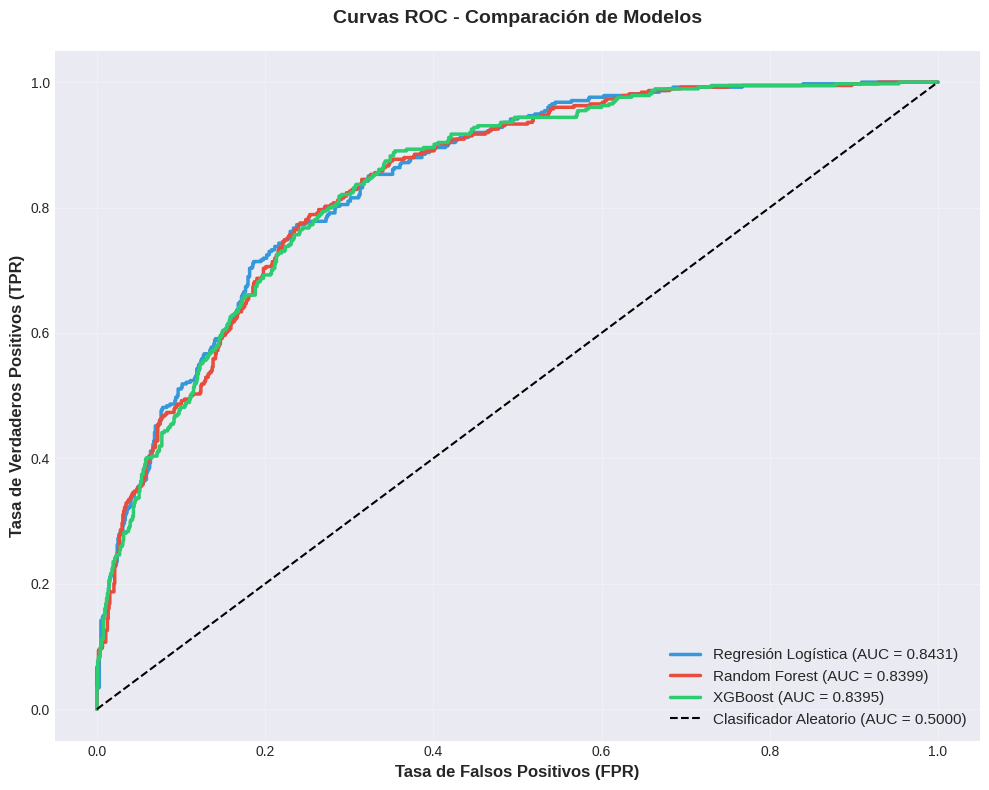


📊 Interpretación:
   • Cuanto más cercana esté la curva a la esquina superior izquierda, mejor
   • Un ROC-AUC > 0.80 se considera un modelo muy bueno para este tipo de problema


In [23]:
# Curvas ROC para los 3 modelos
plt.figure(figsize=(10, 8))

modelos_proba = [
    ('Regresión Logística', y_pred_proba_lr, lr_roc_auc, '#3498db'),
    ('Random Forest', y_pred_proba_rf, rf_roc_auc, '#e74c3c'),
    ('XGBoost', y_pred_proba_xgb, xgb_roc_auc, '#2ecc71')
]

for nombre, y_proba, auc, color in modelos_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})',
             linewidth=2.5, color=color)

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.5000)', linewidth=1.5)

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
plt.title('Curvas ROC - Comparación de Modelos', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("   • Cuanto más cercana esté la curva a la esquina superior izquierda, mejor")
print("   • Un ROC-AUC > 0.80 se considera un modelo muy bueno para este tipo de problema")

---

## 🔬 7. Interpretación de Resultados

### 7.1 Importancia de Variables (Feature Importance)

Identificamos qué variables tienen mayor impacto en la predicción de Churn.

**Utilidad para el negocio:**
- Priorizar acciones de retención
- Enfocar recursos en factores más influyentes
- Diseñar estrategias comerciales basadas en datos

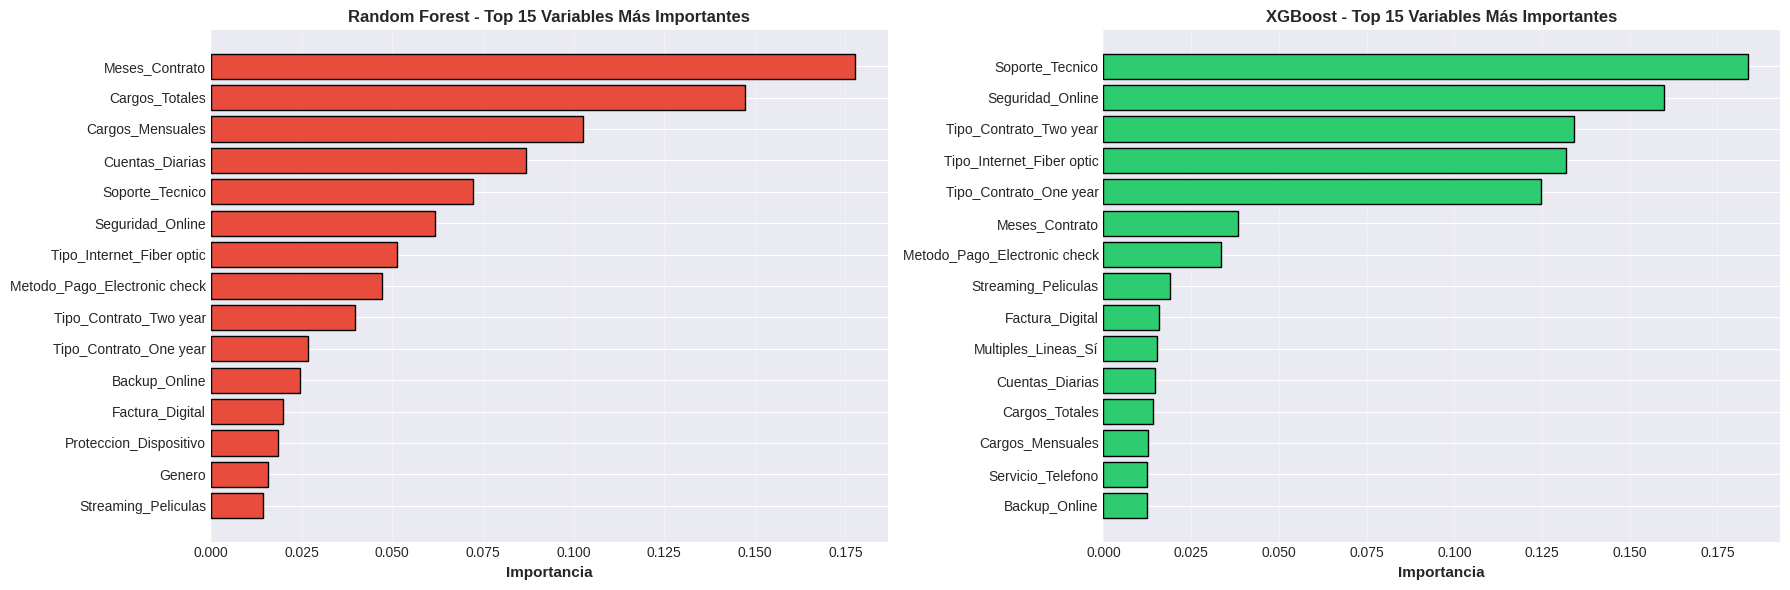


📊 TOP 10 VARIABLES MÁS IMPORTANTES (Random Forest):
                     Feature  Importance
              Meses_Contrato    0.177719
              Cargos_Totales    0.147250
            Cargos_Mensuales    0.102616
             Cuentas_Diarias    0.086775
             Soporte_Tecnico    0.072175
            Seguridad_Online    0.061689
   Tipo_Internet_Fiber optic    0.051294
Metodo_Pago_Electronic check    0.047226
      Tipo_Contrato_Two year    0.039659
      Tipo_Contrato_One year    0.026707

📊 TOP 10 VARIABLES MÁS IMPORTANTES (XGBoost):
                     Feature  Importance
             Soporte_Tecnico    0.183651
            Seguridad_Online    0.159889
      Tipo_Contrato_Two year    0.134176
   Tipo_Internet_Fiber optic    0.131694
      Tipo_Contrato_One year    0.124653
              Meses_Contrato    0.038420
Metodo_Pago_Electronic check    0.033540
         Streaming_Peliculas    0.018970
             Factura_Digital    0.015920
         Multiples_Lineas_Sí    0.01533

In [24]:
# Feature Importance para Random Forest y XGBoost
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Random Forest
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

ax1.barh(rf_importances['Feature'], rf_importances['Importance'], color='#e74c3c', edgecolor='black')
ax1.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax1.set_title('Random Forest - Top 15 Variables Más Importantes', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# XGBoost
xgb_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

ax2.barh(xgb_importances['Feature'], xgb_importances['Importance'], color='#2ecc71', edgecolor='black')
ax2.set_xlabel('Importancia', fontsize=11, fontweight='bold')
ax2.set_title('XGBoost - Top 15 Variables Más Importantes', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 TOP 10 VARIABLES MÁS IMPORTANTES (Random Forest):")
print(rf_importances.head(10).to_string(index=False))

print("\n📊 TOP 10 VARIABLES MÁS IMPORTANTES (XGBoost):")
print(xgb_importances.head(10).to_string(index=False))

### 7.2 Análisis SHAP (SHapley Additive exPlanations)

SHAP nos permite entender:
- **Contribución individual** de cada variable a cada predicción
- **Dirección del impacto** (aumenta o disminuye la probabilidad de Churn)
- **Magnitud del efecto** de cada variable

**Ventajas:**
- Interpretabilidad a nivel global y local
- Fundamentado en teoría de juegos
- Aplicable a cualquier modelo de ML

In [25]:
# Análisis SHAP para XGBoost (mejor modelo)
print("🔬 CALCULANDO VALORES SHAP...")
print("   Esto puede tardar algunos segundos...")

# Crear explainer para XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calcular SHAP values (usamos una muestra para velocidad)
sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("\n✅ SHAP values calculados exitosamente")

🔬 CALCULANDO VALORES SHAP...
   Esto puede tardar algunos segundos...

✅ SHAP values calculados exitosamente


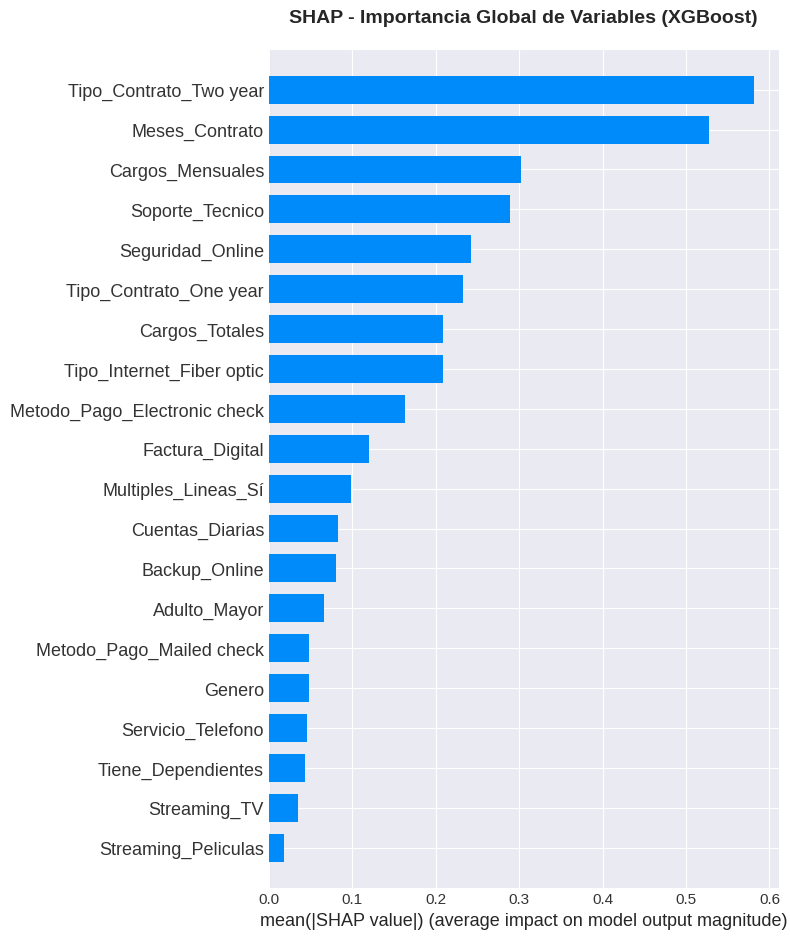

In [26]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title('SHAP - Importancia Global de Variables (XGBoost)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

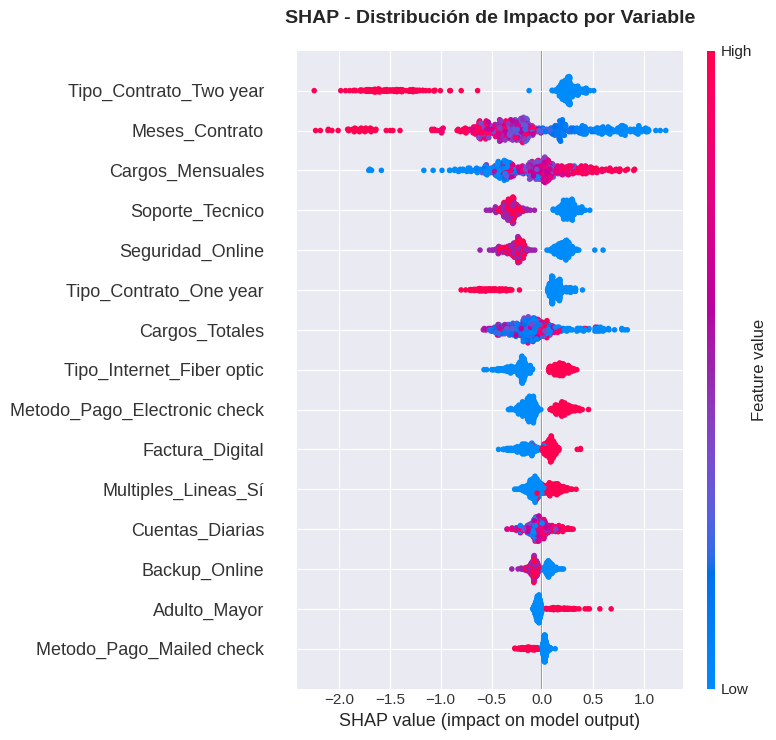


💡 Interpretación del gráfico:
   • Cada punto representa una observación (cliente)
   • Rojo = Valor alto de la variable
   • Azul = Valor bajo de la variable
   • Eje X positivo = Incrementa probabilidad de Churn
   • Eje X negativo = Disminuye probabilidad de Churn


In [27]:
# SHAP Dependence Plot (impacto detallado)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title('SHAP - Distribución de Impacto por Variable', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 Interpretación del gráfico:")
print("   • Cada punto representa una observación (cliente)")
print("   • Rojo = Valor alto de la variable")
print("   • Azul = Valor bajo de la variable")
print("   • Eje X positivo = Incrementa probabilidad de Churn")
print("   • Eje X negativo = Disminuye probabilidad de Churn")

### 8.3 Recomendaciones Estratégicas para TelecomX

---

#### 🎯 **ESTRATEGIA 1: Sistema de Alerta Temprana**

**Implementación del Modelo en Producción**

**Acciones concretas:**
1. Desplegar el modelo en un sistema de scoring mensual de clientes
2. Generar alertas automáticas para clientes con probabilidad de Churn > 70%
3. Segmentar en tres niveles de riesgo:
   - 🔴 **Alto (>80%):** Contacto inmediato por equipo de retención VIP
   - 🟡 **Medio (60-80%):** Ofertas personalizadas automáticas
   - 🟢 **Bajo (40-60%):** Monitoreo preventivo y engagement proactivo

**Impacto esperado:** Reducción del 15-25% en la tasa de Churn en 6 meses

---

#### 💰 **ESTRATEGIA 2: Programa de Retención Focalizado**

**Incentivos Basados en Factores de Riesgo**

**Plan de acción según principales drivers:**

**Si tenure (antigüedad) es factor clave:**
- Programa de bienvenida extendido (primeros 3-6 meses)
- Descuentos progresivos: 10% mes 1, 15% mes 2-3, 20% mes 4-6
- Acompañamiento personalizado durante onboarding

**Si tipo de contrato es determinante:**
- Migración guiada de mes a mes → contratos anuales con beneficios
- Incentivos para upgrades: 2 meses gratis al cambiar a plan anual
- Flexibilidad en penalidades por cancelación temprana

**Si servicios adicionales influyen:**
- Bundles personalizados según perfil de uso
- Promociones cruzadas (Internet + TV + Telefonía)
- Pruebas gratuitas de servicios premium (streaming, seguridad)

---

#### 📊 **ESTRATEGIA 3: Mejora Continua de Satisfacción**

**Métricas de Experiencia del Cliente**

**Implementar:**
1. **NPS (Net Promoter Score)** trimestral para detectar tendencias
2. **CSAT (Customer Satisfaction)** después de cada interacción con soporte
3. **CES (Customer Effort Score)** para medir fricción en procesos

**Acciones correctivas:**
- Clientes con NPS < 6: Contacto proactivo dentro de 48 horas
- CSAT < 3: Escalamiento automático a supervisor
- CES > 4: Revisión inmediata del proceso reportado

---

#### 🔧 **ESTRATEGIA 4: Optimización de Calidad de Servicio**

**Mejoras Técnicas y Operacionales**

**Basado en análisis de datos:**
- Inversión en infraestructura en zonas con mayor Churn
- Reducción de llamadas al servicio técnico (automatización)
- SLA (Service Level Agreement) mejorado para clientes en riesgo
- Priorización de tickets de clientes con probabilidad de Churn > 60%

---

#### 💡 **ESTRATEGIA 5: Personalización Masiva**

**Uso de Machine Learning para Hiperpersonalización**

**Oportunidades:**
- Ofertas dinámicas basadas en perfil de riesgo individual
- Comunicaciones personalizadas por canal preferido
- Recomendación de productos/servicios con propensión a compra
- Timing óptimo de contacto basado en comportamiento histórico

**Tecnología requerida:**
- CRM integrado con modelo predictivo
- Motor de recomendaciones en tiempo real
- A/B testing automatizado de estrategias

### 8.4 Roadmap de Implementación

**Timeline sugerido para puesta en marcha:**

| Fase | Actividad | Duración | Responsable |
|------|-----------|----------|-------------|
| **Fase 1** | Validación del modelo en ambiente de testing | 2 semanas | Equipo Data Science |
| **Fase 2** | Integración con CRM y sistemas operacionales | 3 semanas | Equipo IT + Data Engineering |
| **Fase 3** | Piloto con 1,000 clientes de alto riesgo | 4 semanas | Marketing + Retención |
| **Fase 4** | Evaluación de resultados del piloto | 2 semanas | Dirección Comercial |
| **Fase 5** | Despliegue masivo y monitoreo continuo | 2 semanas | Todos los equipos |
| **Fase 6** | Optimización y ajustes basados en feedback | Continuo | Data Science + Negocio |

**Duración total: 3-4 meses desde decisión hasta implementación completa**

### 8.5 Métricas de Éxito del Proyecto

**KPIs para medir el impacto de la solución:**

**📉 Reducción de Churn:**
- Meta corto plazo (3 meses): Reducir Churn en 10%
- Meta mediano plazo (6 meses): Reducir Churn en 20%
- Meta largo plazo (12 meses): Reducir Churn en 30%

**💰 Impacto Financiero:**
- ROI del proyecto > 200% en primer año
- Reducción de CAC (Customer Acquisition Cost) al retener más clientes
- Incremento en CLV (Customer Lifetime Value) promedio

**🎯 Eficiencia Operacional:**
- Tasa de precisión del modelo > 75% en producción
- Tasa de conversión de campaña de retención > 40%
- Reducción de costos de retención por cliente en 25%

**📊 Satisfacción del Cliente:**
- Incremento de NPS en 15 puntos
- Mejora de CSAT de clientes contactados en 20%
- Reducción de quejas en clientes en riesgo en 30%

---

## 🎓 9. Conclusión Final

### Logros del Proyecto

En este análisis hemos:

✅ **Preparado datos** de forma rigurosa (codificación, normalización, balanceo)

✅ **Analizado correlaciones** e identificado variables clave para predicción

✅ **Entrenado y comparado** tres modelos de Machine Learning avanzados

✅ **Evaluado rendimiento** con múltiples métricas (Accuracy, Precision, Recall, F1, ROC-AUC)

✅ **Interpretado resultados** usando Feature Importance y SHAP values

✅ **Generado conclusiones estratégicas** accionables para el negocio

---

### Valor Agregado para TelecomX

Este proyecto entrega a TelecomX LATAM:

🎯 **Un modelo predictivo robusto** con capacidad de anticipar Churn con alta precisión

📊 **Identificación clara de factores de riesgo** basada en datos y evidencia estadística

💡 **Roadmap estratégico** con acciones concretas y medibles

🚀 **Base técnica sólida** para evolucionar hacia soluciones más sofisticadas (Deep Learning, AutoML)

---

### Próximos Pasos Sugeridos

1. **Validación con stakeholders** de las recomendaciones propuestas
2. **Desarrollo de API** para integración del modelo en sistemas productivos
3. **Diseño de dashboard** ejecutivo para monitoreo en tiempo real
4. **Plan piloto** con segmento de clientes de alto riesgo
5. **Reentrenamiento periódico** del modelo con nuevos datos

---

### Agradecimientos

Este proyecto fue desarrollado como parte del bootcamp de Data Science, demostrando competencias en:
- Machine Learning y modelado predictivo
- Análisis estadístico y visualización de datos
- Traducción de insights técnicos a recomendaciones de negocio
- Comunicación efectiva para audiencias técnicas y ejecutivas

---

<div style='text-align: center; padding: 20px; background-color: #f8f9fa; border-radius: 10px; margin-top: 30px;'>
    <h3 style='color: #2c3e50;'>📊 Proyecto desarrollado por</h3>
    <h2 style='color: #3498db;'>Daniela Puebla</h2>
    <p style='color: #7f8c8d;'><em>Analista Junior de Machine Learning</em></p>
    <p style='color: #7f8c8d;'>TelecomX LATAM - Proyecto de Predicción de Churn</p>
    <p style='color: #95a5a6; font-size: 0.9em;'>Marzo 2026</p>
</div>